# Response Comparison — Frequency Domain vs Time Domain

Compares regular-wave frequency-domain response amplitudes against
time-domain mean peak values from SIMA (HL29, H/λ = 1/29).
Dashed = FD, solid + markers = TD.

In [ ]:
import os, glob
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

HEADINGS       = ['0deg', '45deg', '90deg', '135deg', '180deg']
HEADING_LABELS = {'0deg': r'$0^\circ$', '45deg': r'$45^\circ$', '90deg': r'$90^\circ$',
                  '135deg': r'$135^\circ$', '180deg': r'$180^\circ$'}
HEADING_COLORS = {'0deg': '#1f77b4', '45deg': '#ff7f0e', '90deg': '#2ca02c',
                  '135deg': '#d62728', '180deg': '#9467bd'}

# Resolve this notebook's folder (works in VS Code and standard Jupyter)
NOTEBOOK_DIR = Path(globals().get('__vsc_ipynb_file__', Path.cwd() / '_')).parent
os.chdir(NOTEBOOK_DIR)
import sys
sys.path.insert(0, str(NOTEBOOK_DIR))
from thesis_style import apply, full, save
apply()
print(f'Working directory: {Path.cwd()}')

## Frequency-Domain Results

JONSWAP MPM ($\gamma = 3.3$, 3-hour storm) computed directly from WAMIT CSV files
using the same RAO solver as `Response_AllHeadings.ipynb`.

**Heading convention (WAMIT → SIMA):**

| WAMIT | SIMA |
|-------|------|
| 0°    | 180° |
| 45°   | 135° |
| 90°   | 90°  |
| 135°  | 45°  |
| 180°  | 0°   |

90° is symmetric so it is unambiguous regardless of convention.

In [ ]:
WAMIT_ROOT = NOTEBOOK_DIR.parent.parent / '4_WAMIT RESULTS' / 'BeamSea_90deg_finiteWater' / 'WAMIT_Results'

DOF_LABELS = ["Surge", "Sway", "Heave", "Roll", "Pitch", "Yaw"]
DOF_NAMES  = ["surge", "sway", "heave", "roll", "pitch", "yaw"]
UNITS      = ["m",     "m",    "m",     "deg",  "deg",   "deg"]
r2d        = np.array([1, 1, 1, 180/np.pi, 180/np.pi, 180/np.pi])

# --- Frequency grid ---
_ref  = pd.read_csv(WAMIT_ROOT / 'AddedMass' / 'Added mass 1_surge.csv', sep=';', skiprows=1)
omega = _ref.iloc[:, 0].to_numpy()
N     = len(omega)

# --- Added mass and radiation damping ---
AM_ENTRIES = [
    ("surge", 0,0), ("surge_heave", 0,2), ("surge_pitch", 0,4),
    ("sway",  1,1), ("sway_roll",   1,3), ("sway_yaw",    1,5),
    ("heave", 2,2), ("heave_surge", 2,0), ("heave_pitch", 2,4),
    ("roll",  3,3), ("roll_sway",   3,1), ("roll_yaw",    3,5),
    ("pitch", 4,4), ("pitch_surge", 4,0), ("pitch_heave", 4,2),
    ("yaw",   5,5), ("yaw_sway",    5,1), ("yaw_roll",    5,3),
]
A_tensor = np.zeros((N, 6, 6))
B_tensor = np.zeros((N, 6, 6))
for suffix, i, j in AM_ENTRIES:
    A_tensor[:, i, j] = pd.read_csv(
        WAMIT_ROOT / 'AddedMass' / f'Added mass 1_{suffix}.csv', sep=';', skiprows=1
    ).iloc[:, 1].to_numpy()
    B_tensor[:, i, j] = pd.read_csv(
        WAMIT_ROOT / 'Damping' / f'Radiation damping 1_{suffix}.csv', sep=';', skiprows=1
    ).iloc[:, 1].to_numpy()

# --- Excitation forces (all WAMIT headings) ---
WAMIT_HDG = {"0°": ("0deg","0"), "45°": ("45deg","45"), "90°": ("90deg","90"),
             "135°": ("135deg","135"), "180°": ("180deg","180")}
F_all = {}
for label, (folder, hdg) in WAMIT_HDG.items():
    mag_list, pha_list = [], []
    for dof in DOF_NAMES:
        mag_f = WAMIT_ROOT / folder / 'Fexc'    / f'Excitation Force 1_{dof} heading {hdg}_0o mag.csv'
        pha_f = WAMIT_ROOT / folder / 'FexcPha' / f'Excitation Force 1_{dof} heading {hdg}_0o phase.csv'
        mag_list.append(pd.read_csv(mag_f, sep=';', skiprows=1).iloc[:, 1].to_numpy())
        pha_list.append(pd.read_csv(pha_f, sep=';', skiprows=1).iloc[:, 1].to_numpy())
    F_all[label] = np.column_stack(mag_list) * np.exp(1j * np.column_stack(pha_list))

# --- System stiffness matrix (hydrostatic + mooring + fender) ---
C_hs = np.array([[0,0,0,0,0,0],[0,0,0,0,0,0],
                 [0,0,8.2e7,0,8.9e8,0],[0,0,0,4.0e9,0,0],
                 [0,0,8.9e8,0,3.6e11,0],[0,0,0,0,0,0]])
C_moor = np.array([
    [ 426074.9438,    -2034.0804,      400.6152,    23266.6842,   1182793.4103,  -2271882.4114],
    [  -2034.0804,  711624.6381,   -88838.8566, -5379820.4124,   -376483.6615,  -1900056.8801],
    [    400.6152,  -88838.8566,    24760.7743,   852783.3355,     77503.0783,    353216.9772 ],
    [  23266.6842, -5379820.4124,   852783.3355, 44561633.2487,  4362987.5927,  20752393.8847],
    [1182793.4103,  -376483.6615,    77503.0783,  4362987.5927, 234112685.3010, 956091676.9923],
    [-2271882.4114,-1900056.8801,   353216.9772, 20752393.8847, 956091676.9923, 8345737903.0475]
])
rho, V_ship, L_ship, B_ship = 1025.0, 82520.1, 250.0, 36.0
m   = rho * V_ship
cg  = [-4.8, 0.0, 3.0]
I4  = m * (0.35 * B_ship)**2;  I5 = m * (0.25 * L_ship)**2;  I6 = m * (0.25 * L_ship)**2
Mzg = m * cg[2];               I46 = m * cg[0] * cg[2]
M_mat = np.array([
    [m,    0,   0,     0,   Mzg,    0],
    [0,    m,   0,  -Mzg,    0,    0],
    [0,    0,   m,     0,    0,    0],
    [0,  -Mzg,  0,    I4,    0, -I46],
    [Mzg,  0,   0,     0,   I5,    0],
    [0,    0,   0,  -I46,    0,   I6],
])
fender_dist  = np.array([0.0,-0.25,-0.5,-0.75,-0.95,-1.05,-1.25,-1.5,-1.75,-1.95,-2.05,-2.25,-2.5])
fender_force = np.array([0.0,8.1818e5,1.2424e6,1.3939e6,1.272e6,1.272e6,
                         1.6205e6,2.0e6,1.9303e6,1.8083e6,1.8083e6,2.8227e6,5.053e6])
delta_op  = 6 * 0.03
k_fender  = np.interp(delta_op, np.abs(fender_dist), fender_force) / delta_op
C_fender  = np.zeros((6, 6))
C_fender[1, 1] = 6 * k_fender
C_fender[5, 5] = 2 * k_fender * sum(x**2 for x in [10.0, 30.0, 50.0])
C_tot = C_hs + C_moor + C_fender

# --- RAO ---
RAO_all = {}
for label, F_vec in F_all.items():
    RAO = np.zeros((N, 6), dtype=complex)
    for k, w in enumerate(omega):
        Z = -w**2 * (M_mat + A_tensor[k]) + 1j * w * B_tensor[k] + C_tot
        RAO[k] = np.linalg.solve(Z, F_vec[k])
    RAO_all[label] = RAO

# --- Hs/Tp grid (HL29, first 7 conditions) ---
_g    = 9.81
HS_FD = np.linspace(0.5, 3.5, 10)[:7]
TP_FD = np.sqrt(HS_FD * 2 * np.pi * 29 / _g)

def jonswap(omega, Hs, Tp, gamma=3.3):
    wp  = 2 * np.pi / Tp
    sig = np.where(omega <= wp, 0.07, 0.09)
    r   = np.exp(-(omega - wp)**2 / (2 * sig**2 * wp**2))
    S   = omega**(-5) * np.exp(-1.25 * (wp / omega)**4) * gamma**r
    m0  = np.trapezoid(S, omega)
    return S * Hs**2 / (16 * m0)

T_storm = 3 * 3600
irr_mpm = {}
for label, RAO in RAO_all.items():
    mpm = np.zeros((len(HS_FD), 6))
    for i, (hs, tp) in enumerate(zip(HS_FD, TP_FD)):
        Sw = jonswap(omega, hs, tp)
        for j in range(6):
            H2  = np.abs(RAO[:, j])**2
            Sx  = H2 * Sw
            m0  = np.trapezoid(Sx, omega)
            m2  = np.trapezoid(omega**2 * Sx, omega)
            Tz  = 2 * np.pi * np.sqrt(m0 / m2)
            mpm[i, j] = np.sqrt(2 * m0) * np.sqrt(np.log(T_storm / Tz)) * r2d[j]
    irr_mpm[label] = mpm

# --- Map WAMIT headings → SIMA headings ---
WAMIT_TO_SIMA = {"180°": "0deg", "135°": "45deg", "90°": "90deg",
                 "45°": "135deg", "0°": "180deg"}
FD = {
    sima_key: {DOF_LABELS[j]: irr_mpm[wamit_label][:, j] for j in range(6)}
    for wamit_label, sima_key in WAMIT_TO_SIMA.items()
}

print('FD MPM loaded for:', list(FD.keys()))
for h, d in FD.items():
    print(f"  {h}: Sway @ Hs=2.50m = {d['Sway'][-1]:.4f} m")

## Time-Domain Results — SIMA HL29

Mean of per-seed peak absolute values across all seeds for each condition.

In [3]:
g         = 9.81
N_COND    = 10
HS_VALUES = np.linspace(0.5, 3.5, N_COND)

HL29 = {
    'n': 29, 'base': 'BerthedTanker_Catenary/Run12',
    'dynamic': 'HL29/DynamicResults_HL29_run12-1.h5',
    'n_cond': 7,
}
nc      = HL29['n_cond']
Hs_vals = HS_VALUES[:nc]
Tp_vals = np.sqrt(Hs_vals * 2 * np.pi * HL29['n'] / g)
HL29['cond_params'] = {
    i + 1: (round(float(hs), 2), round(float(tp), 2))
    for i, (hs, tp) in enumerate(zip(Hs_vals, Tp_vals))
}

DOF_CHANNELS = {
    'Surge': 'XGtranslationTotalmotion',
    'Sway':  'YGtranslationTotalmotion',
    'Heave': 'ZGtranslationTotalmotion',
    'Roll':  'XLrotationTotalmotion',
    'Pitch': 'YLrotationTotalmotion',
    'Yaw':   'ZGrotationTotalmotion',
}
R2D = {dof: 1.0 for dof in DOF_LABELS}  # SIMA outputs all channels in SI: m and deg


In [4]:
rows = []

for heading in HEADINGS:
    print('=== ' + heading + ' ===')
    dyn_base  = f"{heading}/{HL29['dynamic']}".rsplit('-', 1)[0]
    dyn_files = sorted(
        glob.glob(f"{dyn_base}-*.h5"),
        key=lambda p: int(p.rsplit('-', 1)[-1].replace('.h5', ''))
    )
    run_key = HL29['base'].split('/')[-1]
    print(f"  {len(dyn_files)} seed(s) found")

    for seed_idx, dyn_file in enumerate(dyn_files):
        try:
            with h5py.File(dyn_file, 'r') as fd:
                root   = list(fd.keys())[0]
                base_d = f"{root}/{run_key}"
                for cond_key in fd[base_d].keys():
                    n   = int(cond_key.split('_')[-1])
                    grp = fd[f"{base_d}/{cond_key}/Dynamic/Tanker/Global total position"]
                    hs, tp = HL29['cond_params'].get(n, (float('nan'), float('nan')))
                    row = {'heading': heading, 'cond_num': n, 'seed': seed_idx, 'Hs': hs, 'Tp': tp}
                    for dof in DOF_LABELS:
                        ts     = grp[DOF_CHANNELS[dof]][:] * R2D[dof]
                        ts_dyn = ts - np.mean(ts)
                        row[dof] = float(np.max(np.abs(ts_dyn)))
                    rows.append(row)
        except FileNotFoundError:
            pass

df_td = pd.DataFrame(rows)
print(f"Total rows: {len(df_td)}")
df_td


=== 0deg ===
  5 seed(s) found
=== 45deg ===
  5 seed(s) found


=== 90deg ===
  5 seed(s) found
=== 135deg ===
  5 seed(s) found


=== 180deg ===
  5 seed(s) found
Total rows: 175


,heading,cond_num,seed,Hs,Tp,Surge,Sway,Heave,Roll,Pitch,Yaw
0,0deg,1,0,0.50,3.05,0.005369,0.000730,0.000813,0.004100,0.000950,0.001904
1,0deg,2,0,0.83,3.93,0.014364,0.001370,0.002458,0.009834,0.004933,0.004738
2,0deg,3,0,1.17,4.66,0.039902,0.003338,0.009316,0.053867,0.017856,0.007656
3,0deg,4,0,1.50,5.28,0.143665,0.006766,0.019703,0.115480,0.037508,0.010772
4,0deg,5,0,1.83,5.84,0.154054,0.006499,0.034398,0.103998,0.069358,0.015214
...,...,...,...,...,...,...,...,...,...,...,...
170,180deg,3,4,1.17,4.66,0.010566,0.002086,0.006674,0.018871,0.008964,0.003137
171,180deg,4,4,1.50,5.28,0.021100,0.004177,0.016805,0.067190,0.020996,0.004817
172,180deg,5,4,1.83,5.84,0.099828,0.005569,0.033798,0.106924,0.041114,0.006925
173,180deg,6,4,2.17,6.34,0.124642,0.006965,0.055900,0.110872,0.072083,0.009526


## Comparison — FD MPM vs TD seed peaks

Dashed: frequency-domain JONSWAP MPM. Faint dots: maximum amplitude from each individual seed realisation. Solid + markers: mean of seed maxima.

### Heading: $0^\circ$

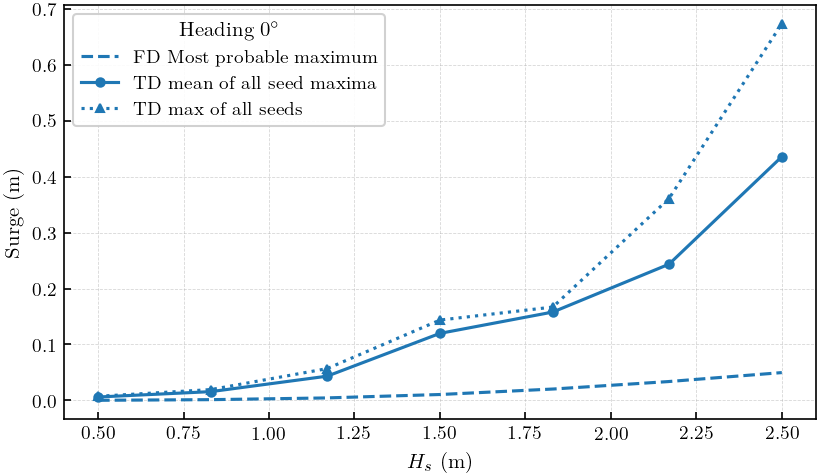

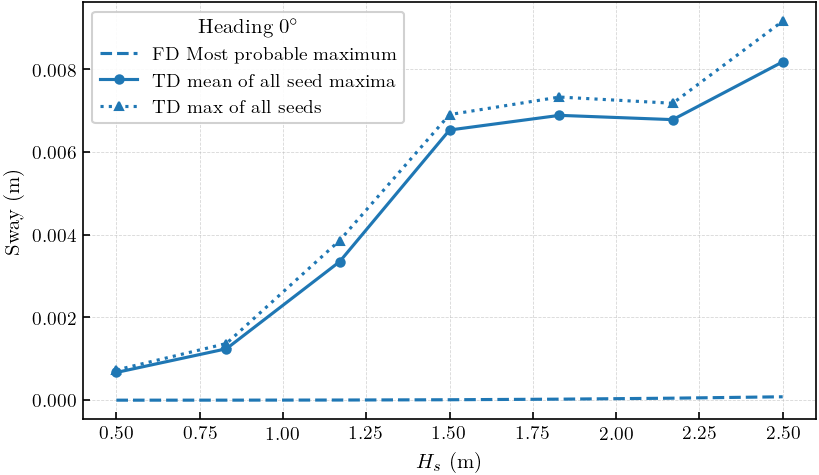

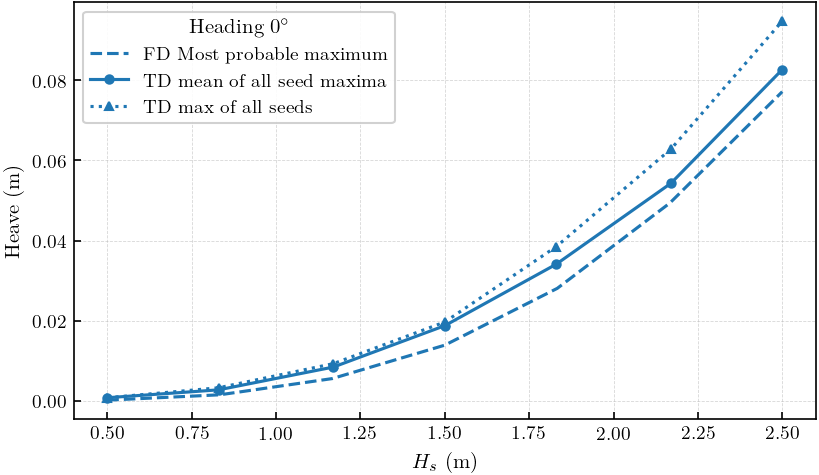

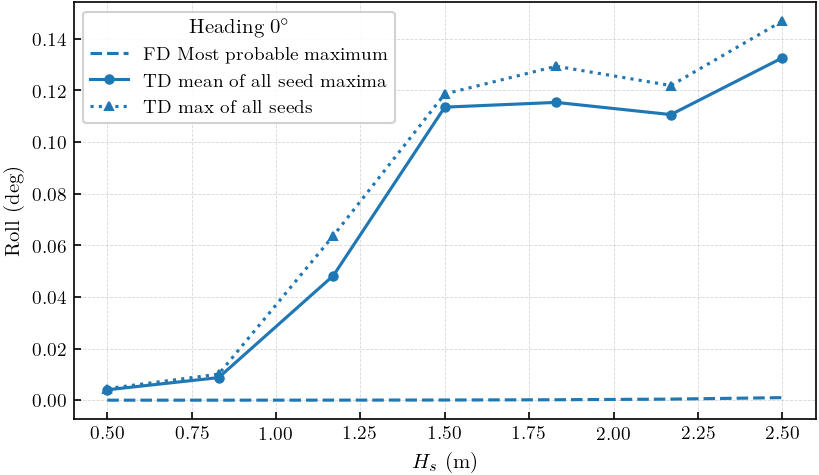

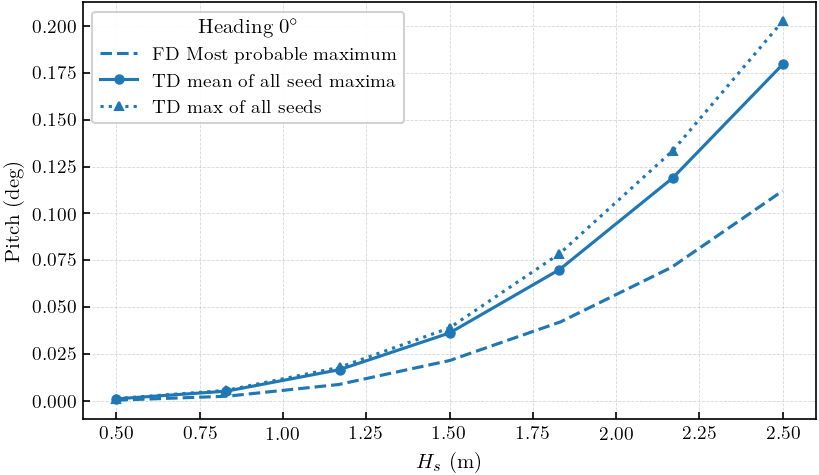

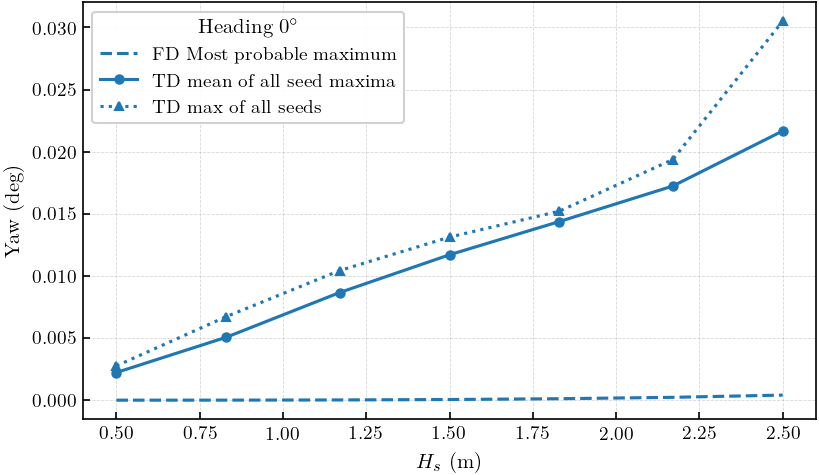

### Heading: $45^\circ$

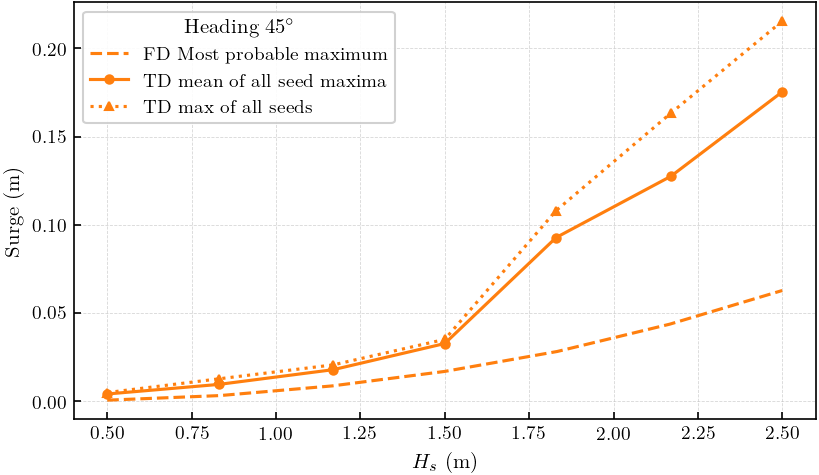

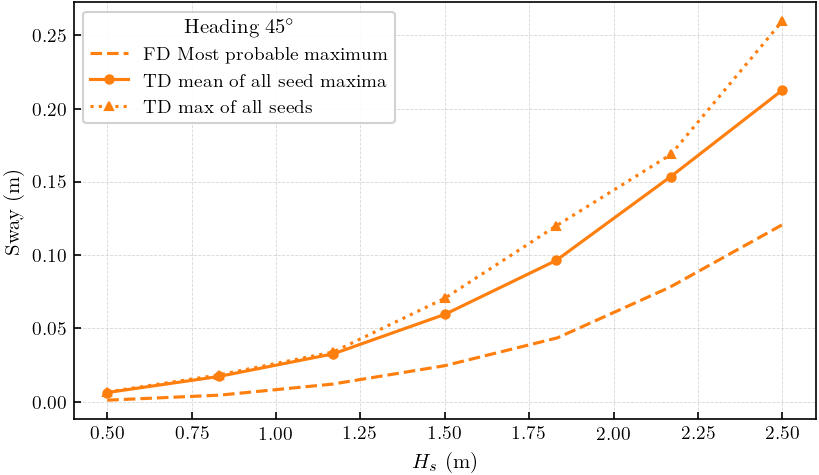

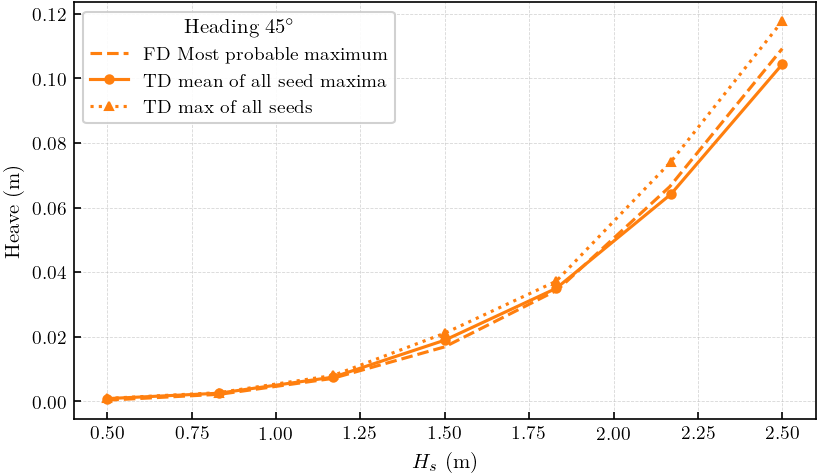

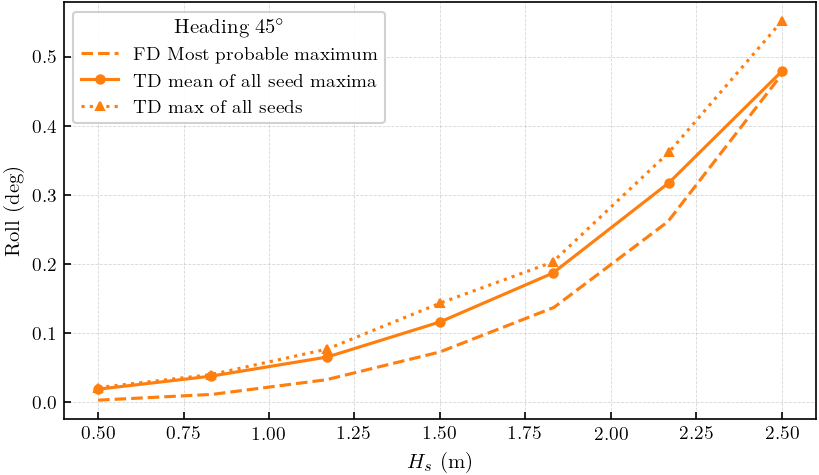

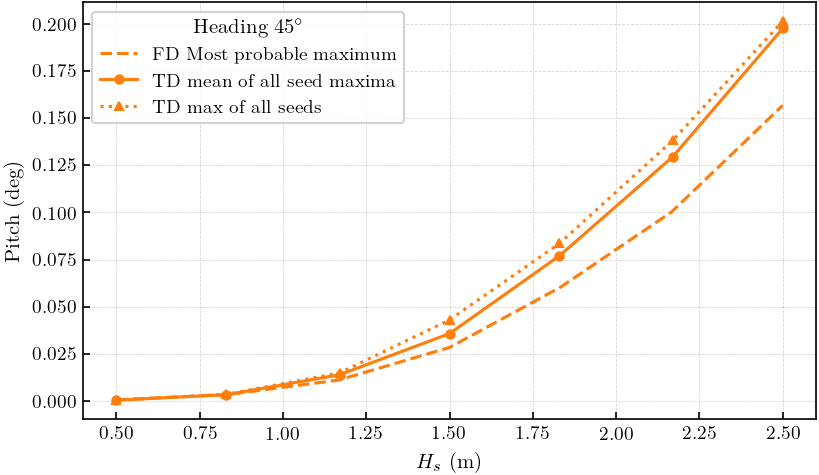

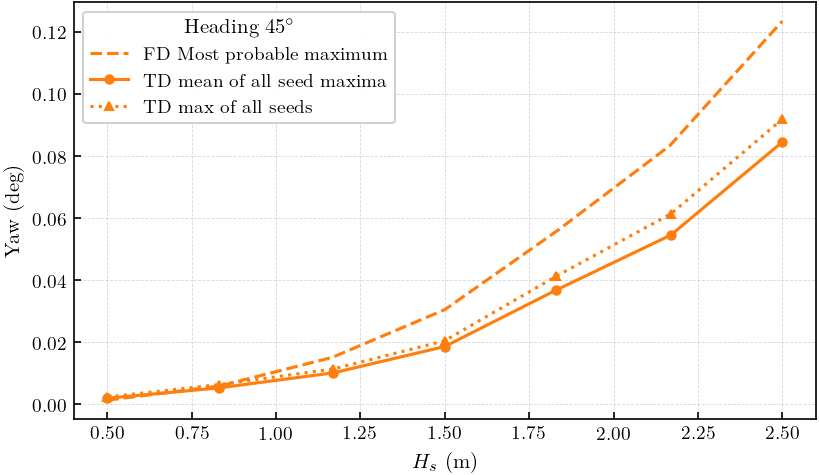

### Heading: $90^\circ$

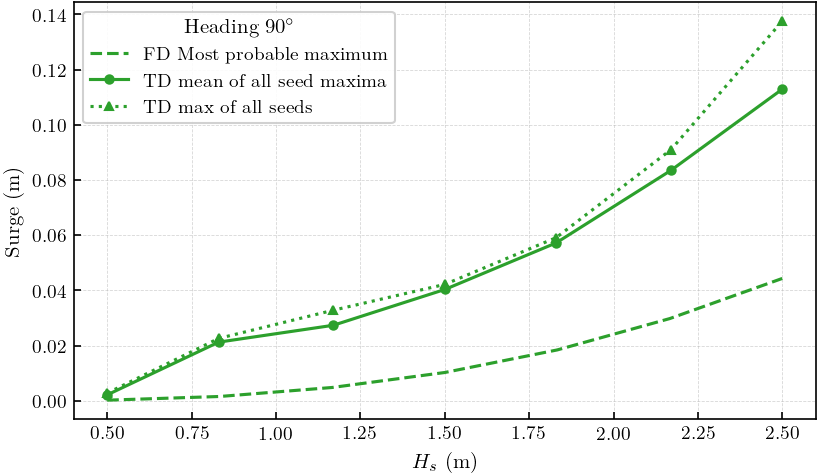

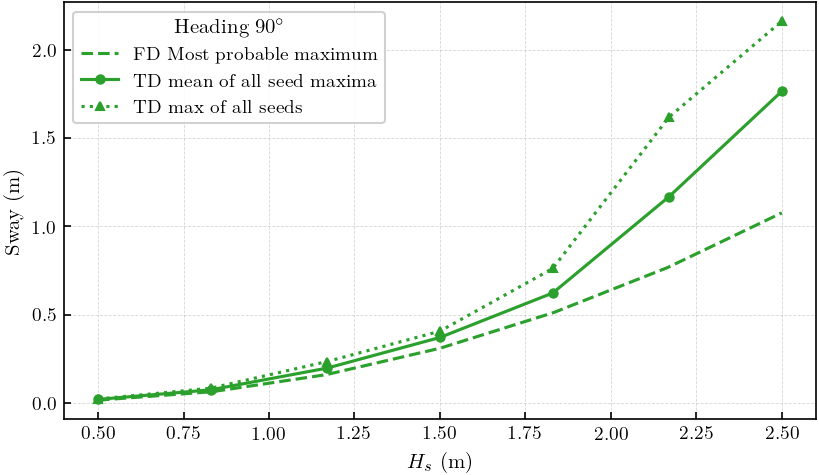

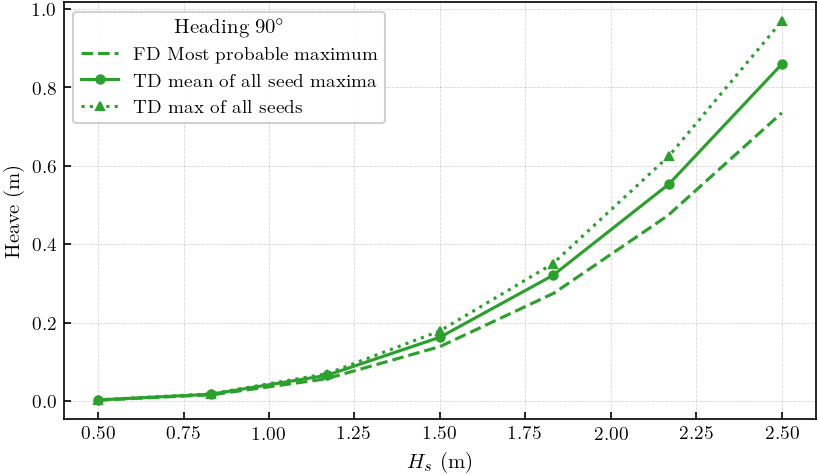

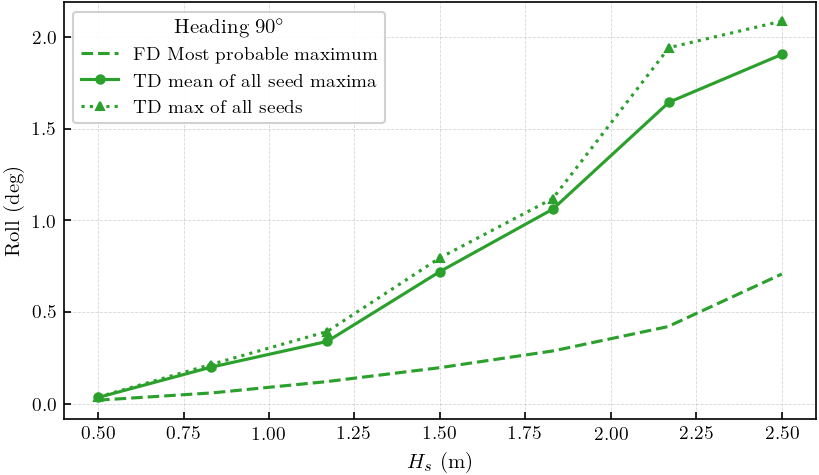

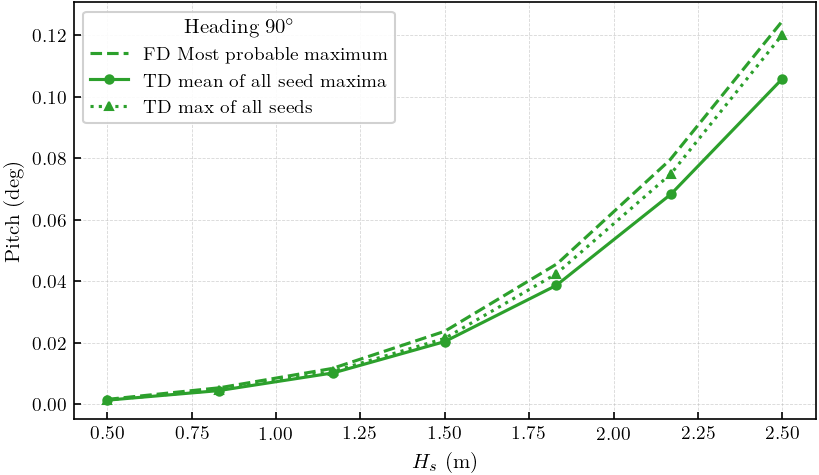

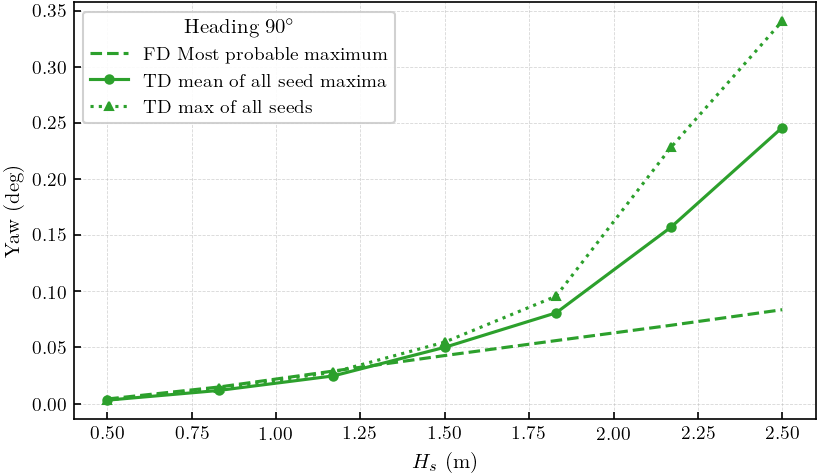

### Heading: $135^\circ$

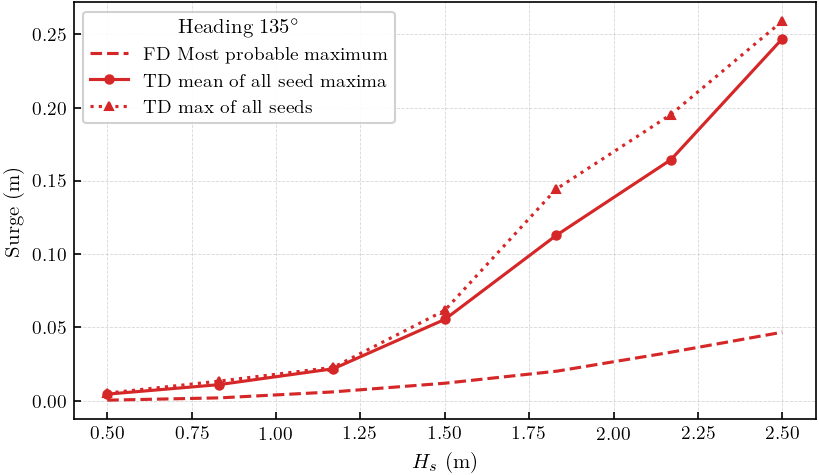

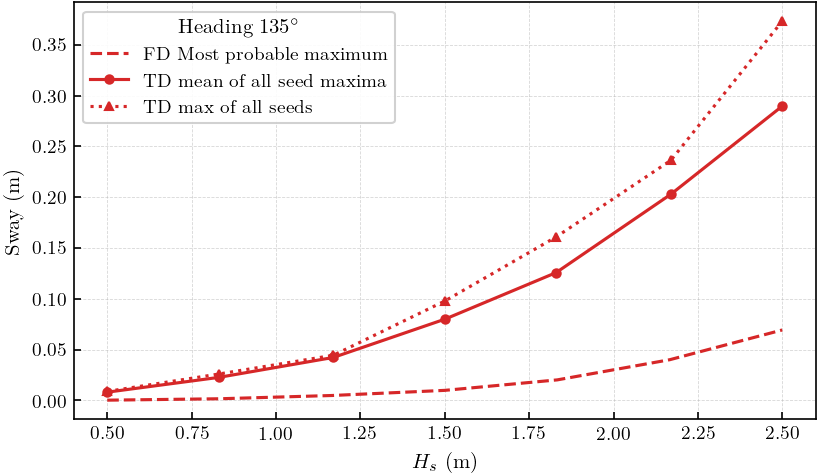

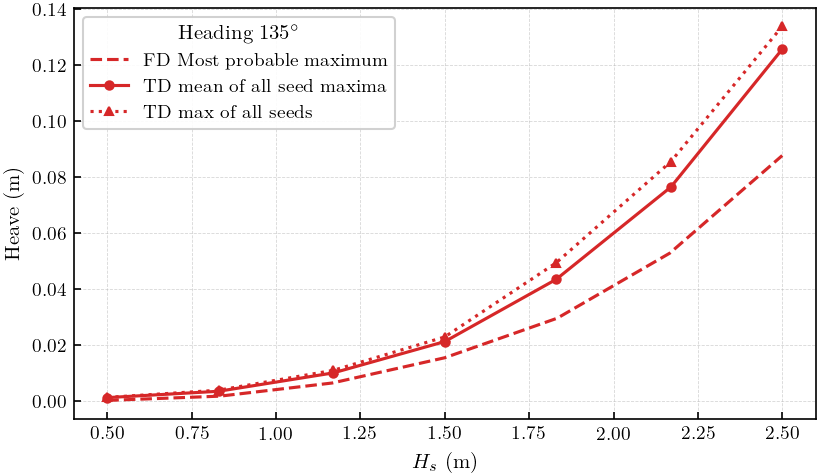

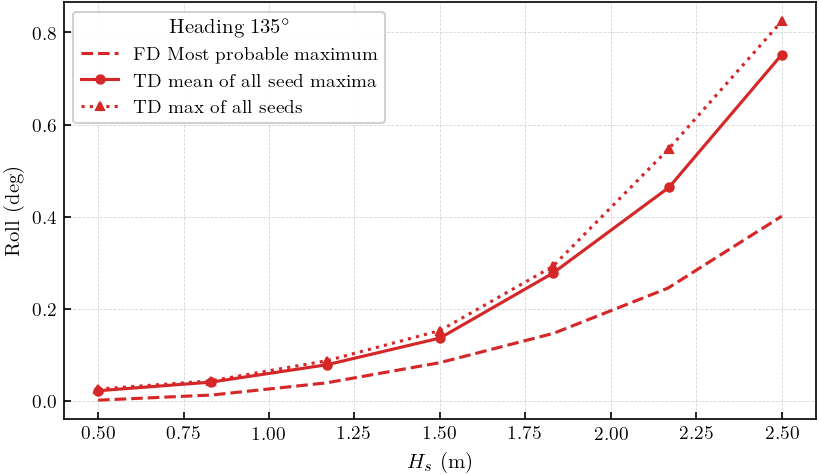

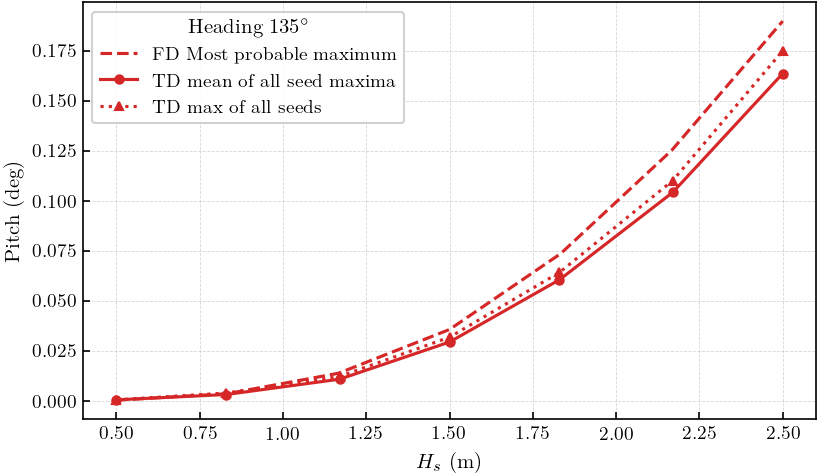

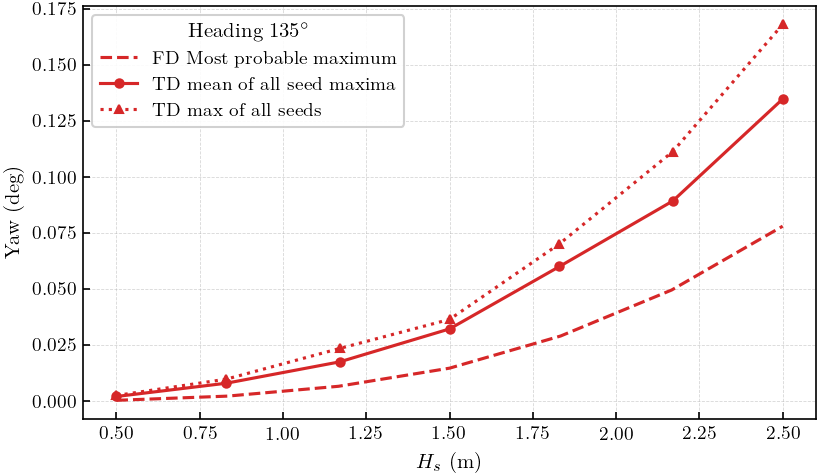

### Heading: $180^\circ$

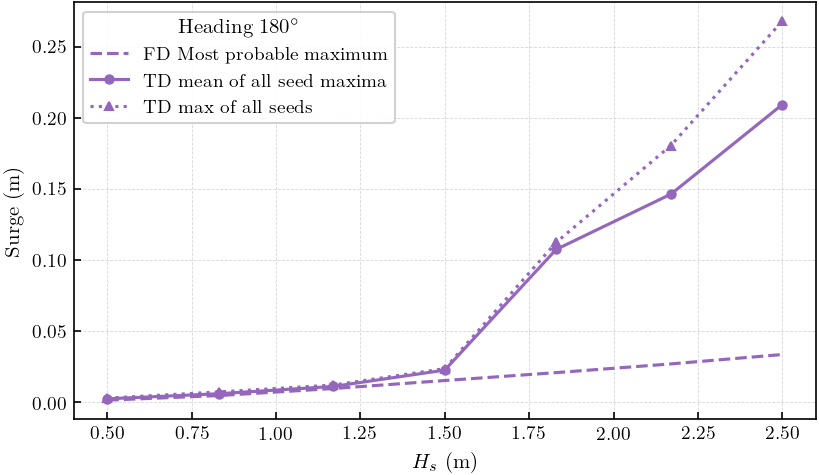

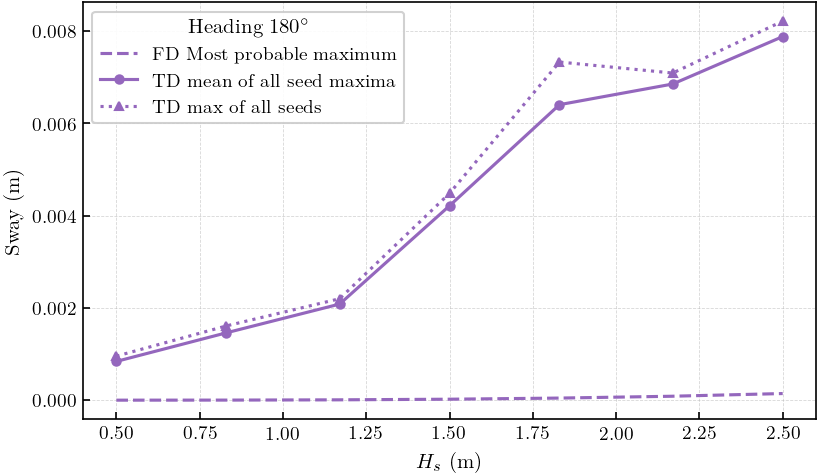

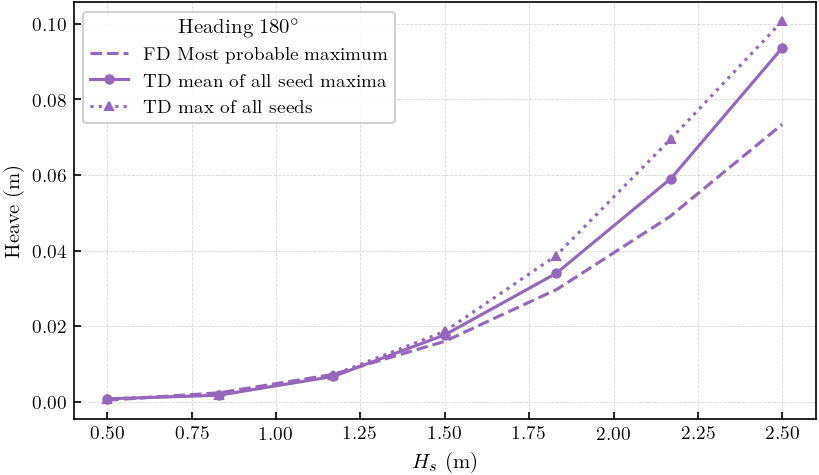

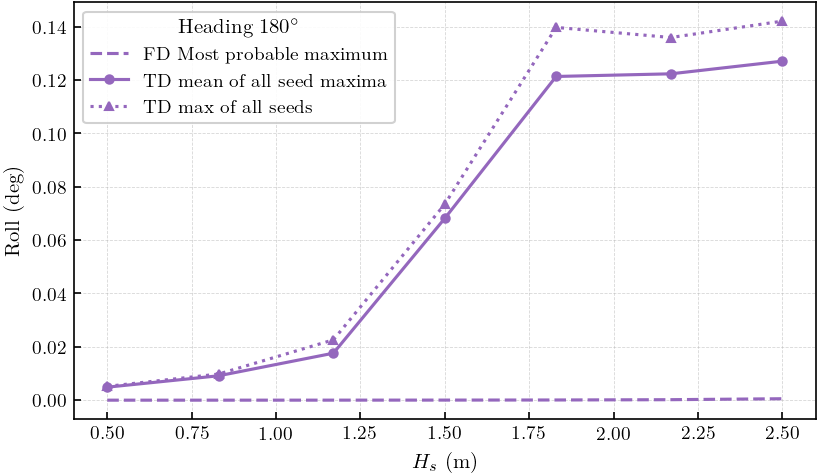

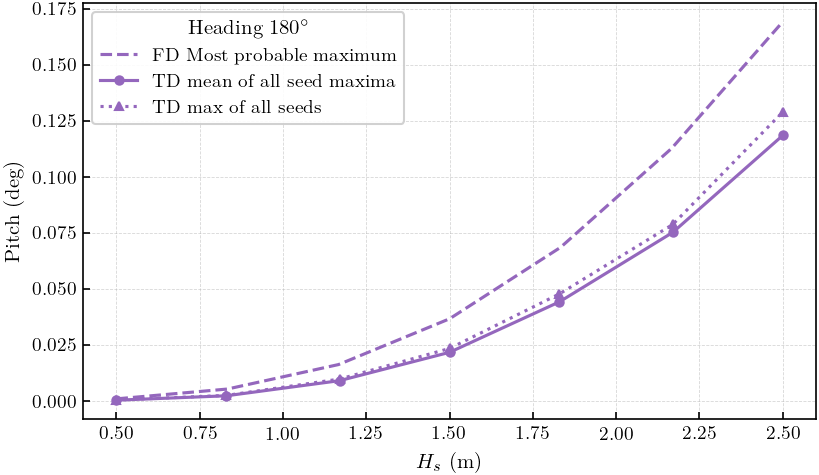

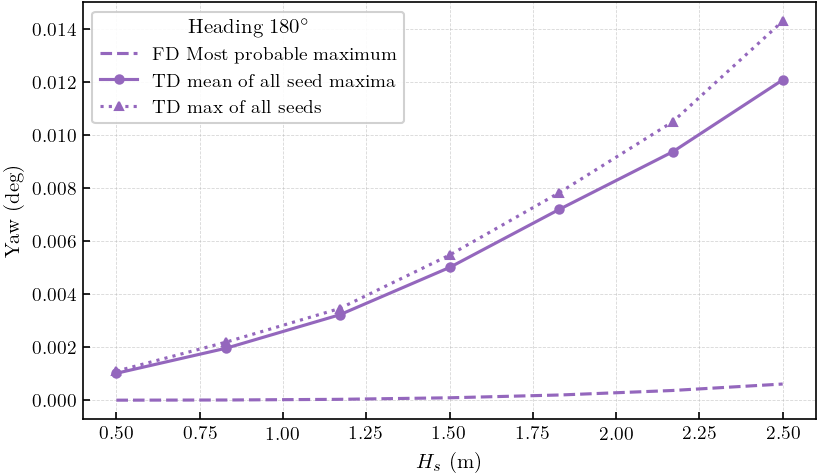

In [5]:
from IPython.display import display, Markdown

for heading in HEADINGS:
    display(Markdown(f"### Heading: {HEADING_LABELS[heading]}"))
    color = HEADING_COLORS[heading]
    label = HEADING_LABELS[heading]
    sub_h = df_td[df_td.heading == heading].sort_values('Hs')

    for dof, unit in zip(DOF_LABELS, UNITS):
        grouped = sub_h.groupby('Hs')[dof]
        max_td  = grouped.max().reset_index()
        mean_td = grouped.mean().reset_index()

        fig, ax = plt.subplots(figsize=full())

        ax.plot(HS_FD, FD[heading][dof],
                color=color, ls='--', lw=1.5, label='FD Most probable maximum')
        ax.plot(mean_td['Hs'], mean_td[dof],
                color=color, ls='-', lw=1.5, marker='o', ms=4,
                label='TD mean of all seed maxima')
        ax.plot(max_td['Hs'], max_td[dof],
                color=color, ls=':', lw=1.5, marker='^', ms=4,
                label='TD max of all seeds')

        ax.set_xlabel('$H_s$ (m)')
        ax.set_ylabel(f'{dof} ({unit})')
        ax.legend(title=f'Heading {HEADING_LABELS[heading]}')
        plt.tight_layout()
        save(fig, f'response_{dof.lower()}_{heading}')
        plt.show()